In [1]:
pip install transformers datasets torch peft accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 11.5 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import get_peft_model, LoraConfig, TaskType
import torch

model_name = "distilgpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(model_name)

total_params = sum(p.numel() for p in base_model.parameters())
print(f"Base model parameters: {total_params:,}")
# Output: 81,912,576

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Base model parameters: 81,912,576


In [3]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,  
    r=8,                          
    lora_alpha=32,                 
    lora_dropout=0.1,          
    target_modules=["c_attn"],     
)

model = get_peft_model(base_model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters with LoRA: {trainable:,}")
print(f"Percentage of model being trained: {trainable/total_params*100:.2f}%")

Trainable parameters with LoRA: 147,456
Percentage of model being trained: 0.18%


/opt/anaconda3/envs/research/lib/python3.11/site-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


In [4]:
from datasets import load_dataset

def prepare_dataset(dataset, text_col, max_examples=300):
    dataset = dataset.select(range(max_examples))

    def tokenize(example):
        return tokenizer(
            example[text_col],
            truncation=True,
            max_length=128,
            padding="max_length"
        )

    tokenized = dataset.map(tokenize, batched=True)
    tokenized = tokenized.remove_columns(
        [c for c in tokenized.column_names
         if c not in ["input_ids", "attention_mask"]]
    )
    tokenized.set_format("torch")
    return tokenized

# Task A - medical Q&A
raw_medical = load_dataset("medalpaca/medical_meadow_medqa", split="train")
raw_medical = raw_medical.map(
    lambda x: {"text": f"Question: {x['input']}\nAnswer: {x['output']}"}
)
task_A = prepare_dataset(raw_medical, "text")

# Task B - general instruction following
raw_general = load_dataset("tatsu-lab/alpaca", split="train")
raw_general = raw_general.map(
    lambda x: {"text": f"Instruction: {x['instruction']}\nResponse: {x['output']}"}
)
task_B = prepare_dataset(raw_general, "text")

print(f"Task A size: {len(task_A)}")
print(f"Task B size: {len(task_B)}")

Map:   0%|          | 0/10178 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Map:   0%|          | 0/52002 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Task A size: 300
Task B size: 300


In [5]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

def train_adapter(model, dataset, output_dir, epochs=3):
    data_collator = DataCollatorForLanguageModeling(
        tokenizer=tokenizer, mlm=False
    )
    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=epochs,
        per_device_train_batch_size=8,
        learning_rate=3e-4,      
        logging_steps=50,
        save_steps=999999,
        report_to="none",
        use_cpu=True
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=dataset,
        data_collator=data_collator
    )
    trainer.train()
    return model

print("Training adapter for Task A (medical)...")
model = train_adapter(model, task_A, "./adapter_task_A")

model.save_pretrained("./adapter_task_A")
print("Task A adapter saved!")

import os
size = sum(
    os.path.getsize(os.path.join("./adapter_task_A", f))
    for f in os.listdir("./adapter_task_A")
) / 1024 / 1024
print(f"Adapter file size: {size:.2f} MB")


Training adapter for Task A (medical)...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
50,3.633172
100,3.357430


Task A adapter saved!
Adapter file size: 0.57 MB


In [6]:
from peft import get_peft_model

base_model_2 = AutoModelForCausalLM.from_pretrained(model_name)
model_B = get_peft_model(base_model_2, lora_config)  # fresh adapter

print("Training adapter for Task B (general instructions)...")
model_B = train_adapter(model_B, task_B, "./adapter_task_B")
model_B.save_pretrained("./adapter_task_B")
print("Task B adapter saved!")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Training adapter for Task B (general instructions)...


Step,Training Loss
50,3.418120
100,3.045384


Task B adapter saved!


In [7]:
from peft import PeftModel

base = AutoModelForCausalLM.from_pretrained(model_name)
model_with_A = PeftModel.from_pretrained(base, "./adapter_task_A")


general_prompts = [
    "The capital of France is",
    "Water boils at 100 degrees",
    "The speed of light is approximately",
    "Albert Einstein was born in",
    "Python is a programming language",
]

medical_prompts = [
    "The most common cause of pneumonia is",
    "Streptococcus bacteria causes",
    "Blood pressure is measured in",
    "The function of the pancreas is",
]

def get_perplexity(prompts, model, tokenizer):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for text in prompts:
            inputs = tokenizer(
                text, return_tensors="pt",
                padding=True, truncation=True, max_length=64
            )
            inputs = {k: v.to("cpu") for k, v in inputs.items()}
            outputs = model(**inputs, labels=inputs["input_ids"])
            total_loss += outputs.loss.item()
    return round(total_loss / len(prompts), 4)

lora_general  = get_perplexity(general_prompts, model_with_A, tokenizer)
lora_medical  = get_perplexity(medical_prompts, model_with_A, tokenizer)

baseline = AutoModelForCausalLM.from_pretrained(model_name)
base_general = get_perplexity(general_prompts, baseline, tokenizer)
base_medical = get_perplexity(medical_prompts, baseline, tokenizer)

print(f"\n{'Metric':<30} {'Baseline':>10} {'LoRA adapter':>14}")
print("-" * 56)
print(f"{'General knowledge perplexity':<30} {base_general:>10} {lora_general:>14}")
print(f"{'Medical perplexity':<30} {base_medical:>10} {lora_medical:>14}")
print(f"\nGeneral knowledge change: {round(lora_general - base_general, 4):+}")
print("(close to 0 = no forgetting, base model stayed frozen)")

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]


Metric                           Baseline   LoRA adapter
--------------------------------------------------------
General knowledge perplexity       5.2281         5.0907
Medical perplexity                   4.94         4.7489

General knowledge change: -0.1374
(close to 0 = no forgetting — base model stayed frozen)


In [8]:
import os

def folder_size_mb(path):
    total = sum(
        os.path.getsize(os.path.join(path, f))
        for f in os.listdir(path)
        if os.path.isfile(os.path.join(path, f))
    )
    return round(total / 1024 / 1024, 1)

full_model_size = round(
    sum(p.numel() * 4 for p in baseline.parameters()) / 1024 / 1024, 1
)

adapter_size = folder_size_mb("./adapter_task_A")

print(f"\nMemory comparison:")
print(f"  Full fine-tuned model:  {full_model_size} MB  (per task)")
print(f"  LoRA adapter:           {adapter_size} MB  (per task)")
print(f"  Saving:                 {round(full_model_size / adapter_size, 0):.0f}x smaller per task")
print(f"\n  10 tasks — full fine-tuning: {full_model_size * 10} MB")
print(f"  10 tasks — LoRA adapters:    {adapter_size * 10} MB + {full_model_size} MB shared base")


Memory comparison:
  Full fine-tuned model:  312.5 MB  (per task)
  LoRA adapter:           0.6 MB  (per task)
  Saving:                 521x smaller per task

  10 tasks — full fine-tuning: 3125.0 MB
  10 tasks — LoRA adapters:    6.0 MB + 312.5 MB shared base


/var/folders/xx/7b_q2xk911n63ph0jnc2vym00000gn/T/ipykernel_64347/1734806011.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


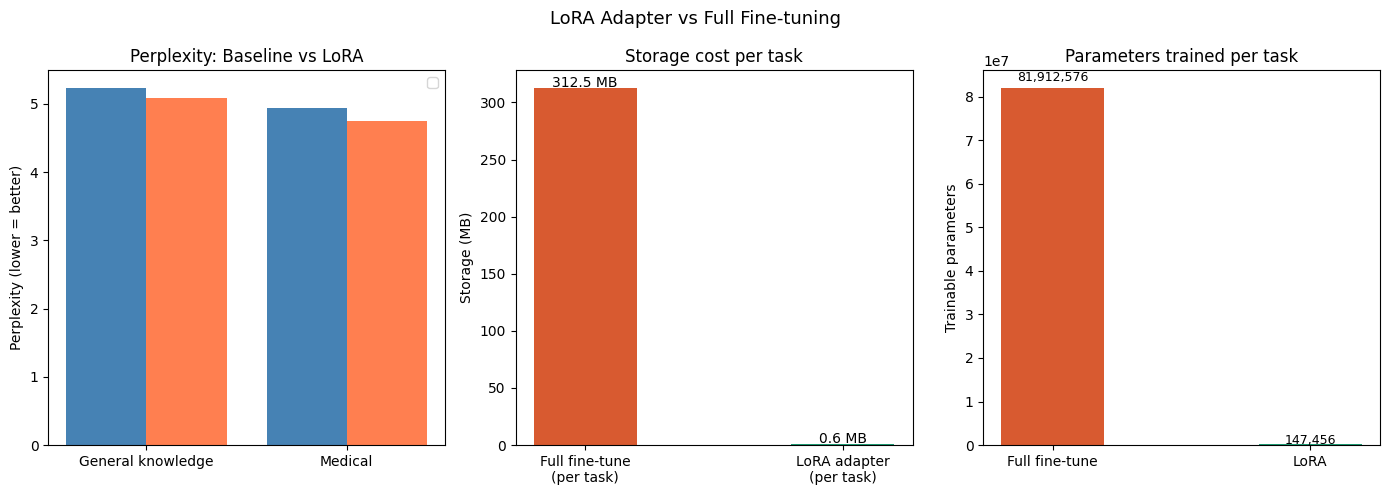

In [10]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

categories = ['General knowledge', 'Medical']
baseline_scores = [base_general, base_medical]
lora_scores     = [lora_general, lora_medical]

x = np.arange(len(categories))
axes[0].bar(x - 0.2, baseline_scores, 0.4, color='steelblue')
axes[0].bar(x + 0.2, lora_scores,     0.4,     color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Perplexity (lower = better)')
axes[0].set_title('Perplexity: Baseline vs LoRA')
axes[0].legend()

strategies = ['Full fine-tune\n(per task)', 'LoRA adapter\n(per task)']
sizes = [full_model_size, adapter_size]
colors = ['#d85a30', '#1d9e75']
axes[1].bar(strategies, sizes, color=colors, width=0.4)
axes[1].set_ylabel('Storage (MB)')
axes[1].set_title('Storage cost per task')
for i, v in enumerate(sizes):
    axes[1].text(i, v + 1, f'{v} MB', ha='center', fontsize=10)

param_labels = ['Full fine-tune', 'LoRA']
param_values = [total_params, trainable]
axes[2].bar(param_labels, param_values, color=['#d85a30', '#1d9e75'], width=0.4)
axes[2].set_ylabel('Trainable parameters')
axes[2].set_title('Parameters trained per task')
for i, v in enumerate(param_values):
    axes[2].text(i, v * 1.02, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('LoRA Adapter vs Full Fine-tuning', fontsize=13, fontweight='500')
plt.tight_layout()
plt.savefig('lora_comparison.png', dpi=150)
plt.show()